<a href="https://colab.research.google.com/github/hackathon-cortex/Adaptive-pathing-/blob/main/VEHICLE_CONTROL_%2B_SIMULINK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Vehicle Control System")
print("Saud Rana  - Vehicle Control + Simulink")

Vehicle Control System
Saud Rana  - Vehicle Control + Simulink


In [ ]:
# Vehicle parameters

vehicle_mass = 1500      # kg
wheelbase = 2.7          # meters
max_speed = 20.0         # m/s
max_acceleration = 3.0   # m/s²
max_braking = 6.0        # m/s²

print("Vehicle Mass:", vehicle_mass, "kg")
print("Wheelbase:", wheelbase, "m")
print("Maximum Speed:", max_speed, "m/s")
print("Maximum Acceleration:", max_acceleration, "m/s²")
print("Maximum Braking:", max_braking, "m/s²")

Vehicle Mass: 1500 kg
Wheelbase: 2.7 m
Maximum Speed: 20.0 m/s
Maximum Acceleration: 3.0 m/s²
Maximum Braking: 6.0 m/s²


In [ ]:
def speed_controller(target_speed, current_speed):
    error = target_speed - current_speed

    Kp = 1.0

    acceleration = Kp * error

    acceleration = np.clip(
        acceleration,
        -max_braking,
        max_acceleration
    )

    return acceleration

In [ ]:
target_speed = 15.0
current_speed = 10.0

acceleration = speed_controller(
    target_speed,
    current_speed
)

print("Target Speed:", target_speed, "m/s")
print("Current Speed:", current_speed, "m/s")
print("Controller Acceleration:", acceleration, "m/s²")

Target Speed: 15.0 m/s
Current Speed: 10.0 m/s
Controller Acceleration: 3.0 m/s²


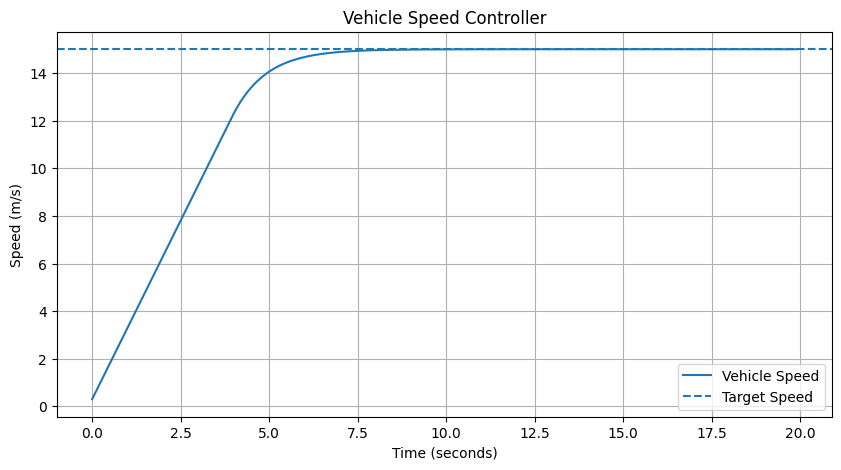

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation settings
dt = 0.1
simulation_time = 20

time = np.arange(0, simulation_time, dt)

# Target speed
target_speed = 15.0  # m/s

# Initial vehicle speed
current_speed = 0.0

# Store results
speed_history = []
acceleration_history = []

# Simulation loop
for t in time:

    acceleration = speed_controller(
        target_speed,
        current_speed
    )

    current_speed += acceleration * dt

    # Keep speed physically valid
    current_speed = np.clip(
        current_speed,
        0,
        max_speed
    )

    speed_history.append(current_speed)
    acceleration_history.append(acceleration)


# Plot speed
plt.figure(figsize=(10, 5))

plt.plot(
    time,
    speed_history,
    label="Vehicle Speed"
)

plt.axhline(
    target_speed,
    linestyle="--",
    label="Target Speed"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed Controller")

plt.grid()
plt.legend()
plt.show()

sterring control

In [ ]:
import numpy as np

def steering_controller(target_heading, current_heading):
    error = target_heading - current_heading

    Kp = 1.5

    steering = Kp * error

    # Steering limit: -30° to +30°
    steering = np.clip(
        steering,
        -np.radians(30),
        np.radians(30)
    )

    return steering

In [ ]:
target_heading = np.radians(20)
current_heading = np.radians(5)

steering = steering_controller(
    target_heading,
    current_heading
)

print("Target Heading:", np.degrees(target_heading), "degrees")
print("Current Heading:", np.degrees(current_heading), "degrees")
print("Steering Command:", np.degrees(steering), "degrees")

Target Heading: 20.0 degrees
Current Heading: 5.0 degrees
Steering Command: 22.5 degrees


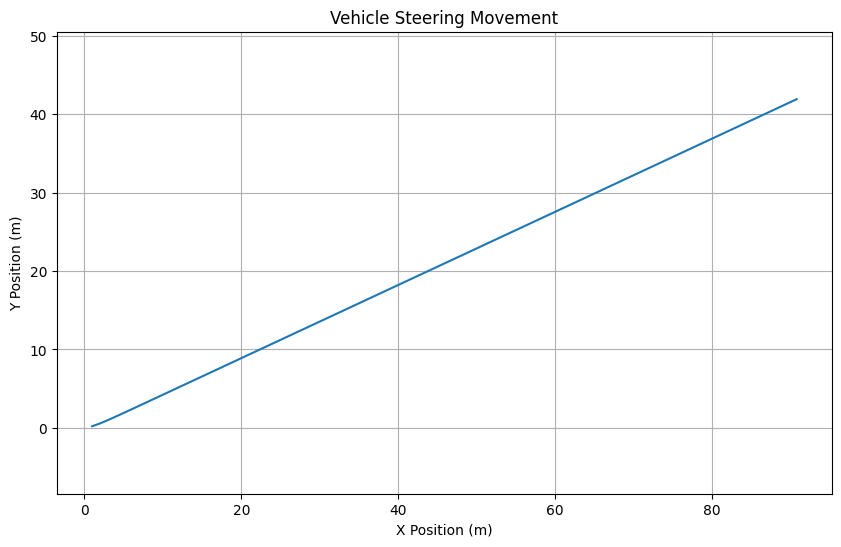

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.1
simulation_time = 10

wheelbase = 2.7
speed = 10.0

x = 0.0
y = 0.0
heading = 0.0

x_history = []
y_history = []
heading_history = []

target_heading = np.radians(25)

for _ in np.arange(0, simulation_time, dt):

    steering = steering_controller(
        target_heading,
        heading
    )

    # Vehicle kinematic model
    heading_rate = (speed / wheelbase) * np.tan(steering)

    heading += heading_rate * dt

    x += speed * np.cos(heading) * dt
    y += speed * np.sin(heading) * dt

    x_history.append(x)
    y_history.append(y)
    heading_history.append(np.degrees(heading))

plt.figure(figsize=(10, 6))

plt.plot(x_history, y_history)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Vehicle Steering Movement")

plt.grid()
plt.axis("equal")
plt.show()

Acceleration & Deceleration Controller

In [ ]:
def acceleration_controller(target_speed, current_speed):
    error = target_speed - current_speed

    Kp = 1.0

    acceleration = Kp * error

    # Limit acceleration and braking
    acceleration = np.clip(
        acceleration,
        -max_braking,
        max_acceleration
    )

    return acceleration

In [ ]:
target_speed = 15.0
current_speed = 5.0

acceleration = acceleration_controller(
    target_speed,
    current_speed
)

print("Target Speed:", target_speed, "m/s")
print("Current Speed:", current_speed, "m/s")
print("Acceleration Command:", acceleration, "m/s²")

Target Speed: 15.0 m/s
Current Speed: 5.0 m/s
Acceleration Command: 3.0 m/s²


In [ ]:
target_speed = 5.0
current_speed = 15.0

acceleration = acceleration_controller(
    target_speed,
    current_speed
)

print("Target Speed:", target_speed, "m/s")
print("Current Speed:", current_speed, "m/s")
print("Deceleration Command:", acceleration, "m/s²")

Target Speed: 5.0 m/s
Current Speed: 15.0 m/s
Deceleration Command: -6.0 m/s²


breaking control

In [ ]:
def braking_controller(target_speed, current_speed):
    if current_speed <= target_speed:
        return 0.0

    speed_error = current_speed - target_speed

    Kp = 1.5

    braking = Kp * speed_error

    braking = np.clip(
        braking,
        0,
        max_braking
    )

    return braking

In [ ]:
target_speed = 5.0
current_speed = 15.0

braking = braking_controller(
    target_speed,
    current_speed
)

print("Target Speed:", target_speed, "m/s")
print("Current Speed:", current_speed, "m/s")
print("Brake Command:", braking, "m/s²")

Target Speed: 5.0 m/s
Current Speed: 15.0 m/s
Brake Command: 6.0 m/s²


In [ ]:
target_speed = 15.0
current_speed = 10.0

braking = braking_controller(
    target_speed,
    current_speed
)

print("Brake Command:", braking, "m/s²")

Brake Command: 0.0 m/s²


Emergency Breaking


In [ ]:
def emergency_brake_controller(
    distance,
    risk_score,
    current_speed
):
    emergency_brake = False
    braking = 0.0

    if distance <= 2.0 or risk_score >= 0.75:
        emergency_brake = True
        braking = max_braking

    return emergency_brake, braking

In [ ]:
distance = 1.5
risk_score = 0.9
current_speed = 12.0

emergency_brake, braking = emergency_brake_controller(
    distance,
    risk_score,
    current_speed
)

print("Distance:", distance, "m")
print("Risk Score:", risk_score)
print("Emergency Brake:", emergency_brake)
print("Braking:", braking, "m/s²")

Distance: 1.5 m
Risk Score: 0.9
Emergency Brake: True
Braking: 6.0 m/s²


In [ ]:
distance = 15.0
risk_score = 0.2
current_speed = 12.0

emergency_brake, braking = emergency_brake_controller(
    distance,
    risk_score,
    current_speed
)

print("Distance:", distance, "m")
print("Risk Score:", risk_score)
print("Emergency Brake:", emergency_brake)
print("Braking:", braking, "m/s²")

Distance: 15.0 m
Risk Score: 0.2
Emergency Brake: False
Braking: 0.0 m/s²


Complete Vehicle Controller

In [ ]:
def vehicle_controller(
    target_speed,
    current_speed,
    target_heading,
    current_heading,
    obstacle_distance,
    risk_score
):
    # Steering
    steering = steering_controller(
        target_heading,
        current_heading
    )

    # Emergency braking
    emergency_brake, emergency_braking = (
        emergency_brake_controller(
            obstacle_distance,
            risk_score,
            current_speed
        )
    )

    if emergency_brake:
        acceleration = -emergency_braking
        speed_command = 0.0

    else:
        # Normal speed control
        acceleration = acceleration_controller(
            target_speed,
            current_speed
        )

        # Normal braking
        braking = braking_controller(
            target_speed,
            current_speed
        )

        if braking > 0:
            acceleration = -braking

        speed_command = target_speed

    return {
        "steering": steering,
        "speed": speed_command,
        "acceleration": acceleration,
        "emergency_brake": emergency_brake
    }

In [ ]:
command = vehicle_controller(
    target_speed=15.0,
    current_speed=10.0,
    target_heading=np.radians(20),
    current_heading=np.radians(5),
    obstacle_distance=20.0,
    risk_score=0.2
)

print("Vehicle Command:")
print(command)

Vehicle Command:
{'steering': np.float64(0.39269908169872414), 'speed': 15.0, 'acceleration': np.float64(3.0), 'emergency_brake': False}


In [ ]:
command = vehicle_controller(
    target_speed=15.0,
    current_speed=12.0,
    target_heading=np.radians(20),
    current_heading=np.radians(5),
    obstacle_distance=1.5,
    risk_score=0.9
)

print("Emergency Vehicle Command:")
print(command)

Emergency Vehicle Command:
{'steering': np.float64(0.39269908169872414), 'speed': 0.0, 'acceleration': -6.0, 'emergency_brake': True}


Trajectory Following

In [ ]:
trajectory = [
    (0, 0),
    (5, 0.5),
    (10, 1.5),
    (15, 3.0),
    (20, 5.0),
    (25, 7.5)
]

print("Trajectory points:")
for point in trajectory:
    print(point)

Trajectory points:
(0, 0)
(5, 0.5)
(10, 1.5)
(15, 3.0)
(20, 5.0)
(25, 7.5)


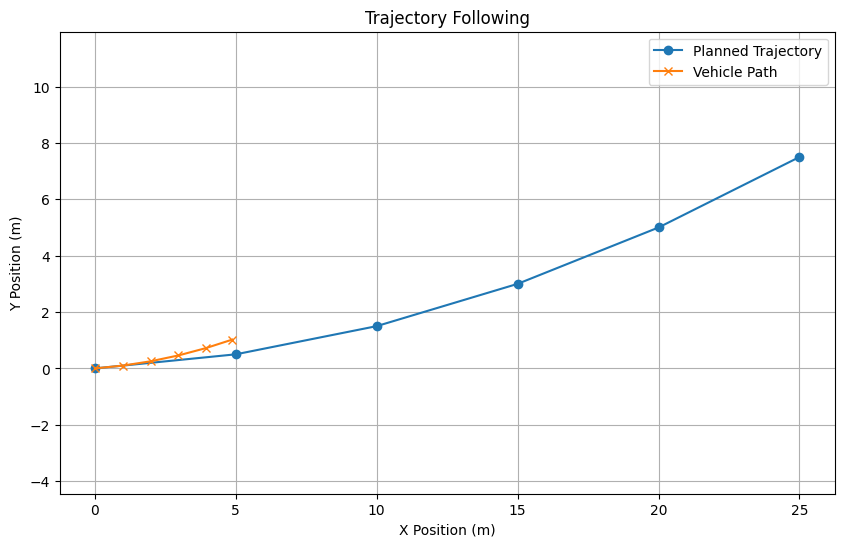

In [ ]:
x = 0.0
y = 0.0

vehicle_path_x = [x]
vehicle_path_y = [y]

for target_x, target_y in trajectory[1:]:

    dx = target_x - x
    dy = target_y - y

    distance = np.sqrt(dx**2 + dy**2)

    if distance == 0:
        continue

    # Move vehicle toward target point
    step = min(1.0, distance)

    x += (dx / distance) * step
    y += (dy / distance) * step

    vehicle_path_x.append(x)
    vehicle_path_y.append(y)

plt.figure(figsize=(10, 6))

plt.plot(
    [p[0] for p in trajectory],
    [p[1] for p in trajectory],
    marker="o",
    label="Planned Trajectory"
)

plt.plot(
    vehicle_path_x,
    vehicle_path_y,
    marker="x",
    label="Vehicle Path"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Trajectory Following")

plt.grid()
plt.axis("equal")
plt.legend()
plt.show()

Proper Vehicle Control Integration


Target trajectory → Steering → Speed control → Vehicle movement


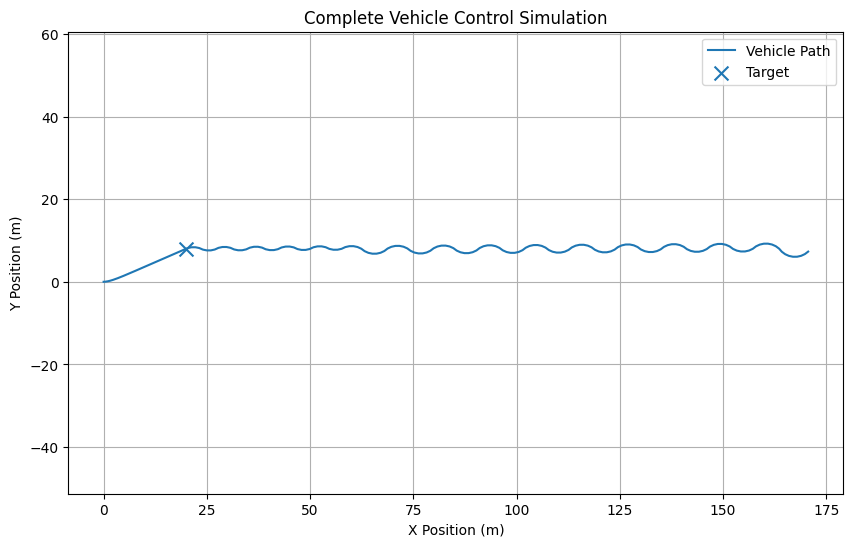

In [ ]:
dt = 0.1
simulation_time = 20

x = 0.0
y = 0.0
heading = 0.0
current_speed = 0.0

target_speed = 10.0

x_history = []
y_history = []
speed_history = []

for _ in np.arange(0, simulation_time, dt):

    # Target point
    target_x = 20.0
    target_y = 8.0

    dx = target_x - x
    dy = target_y - y

    target_heading = np.arctan2(dy, dx)

    # Vehicle controller
    command = vehicle_controller(
        target_speed=target_speed,
        current_speed=current_speed,
        target_heading=target_heading,
        current_heading=heading,
        obstacle_distance=50.0,
        risk_score=0.1
    )

    # Update speed
    current_speed += command["acceleration"] * dt
    current_speed = np.clip(
        current_speed,
        0,
        max_speed
    )

    # Update heading
    steering = command["steering"]

    heading_rate = (
        current_speed / wheelbase
    ) * np.tan(steering)

    heading += heading_rate * dt

    # Update position
    x += current_speed * np.cos(heading) * dt
    y += current_speed * np.sin(heading) * dt

    x_history.append(x)
    y_history.append(y)
    speed_history.append(current_speed)

# Plot vehicle path
plt.figure(figsize=(10, 6))

plt.plot(
    x_history,
    y_history,
    label="Vehicle Path"
)

plt.scatter(
    [20],
    [8],
    marker="x",
    s=100,
    label="Target"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("Complete Vehicle Control Simulation")

plt.grid()
plt.axis("equal")
plt.legend()
plt.show()

Obstacle + Emergency Stop Simulation


In [ ]:
dt = 0.1
simulation_time = 10

current_speed = 10.0

distance = 20.0
risk_score = 0.2

speed_history = []
distance_history = []
brake_history = []
time_history = []

for t in np.arange(0, simulation_time, dt):

    # Obstacle getting closer
    distance -= current_speed * dt

    # Simple risk estimation
    if distance <= 2.0:
        risk_score = 0.9
    elif distance <= 5.0:
        risk_score = 0.7
    elif distance <= 10.0:
        risk_score = 0.5
    else:
        risk_score = 0.2

    # Emergency brake controller
    emergency_brake, braking = emergency_brake_controller(
        distance,
        risk_score,
        current_speed
    )

    if emergency_brake:
        current_speed -= braking * dt
    else:
        current_speed = current_speed

    current_speed = max(0.0, current_speed)

    time_history.append(t)
    speed_history.append(current_speed)
    distance_history.append(max(0.0, distance))
    brake_history.append(braking)

print("Final Speed:", current_speed, "m/s")
print("Final Distance:", max(0.0, distance), "m")

Final Speed: 0.0 m/s
Final Distance: 0.0 m


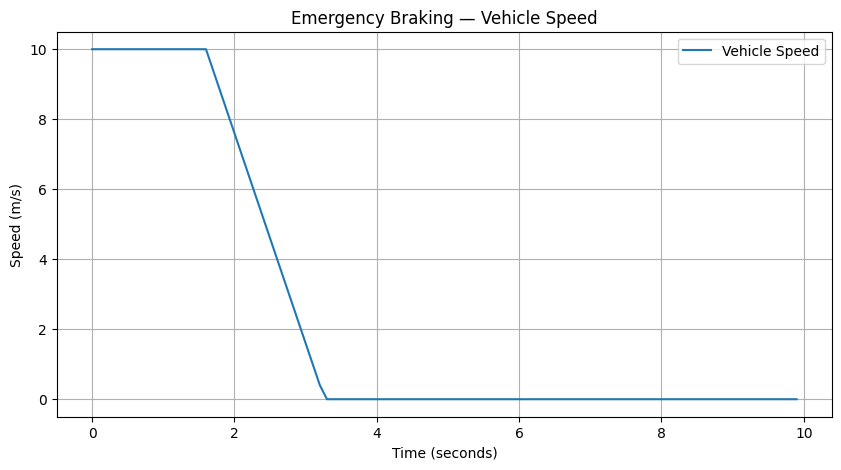

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    speed_history,
    label="Vehicle Speed"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Emergency Braking — Vehicle Speed")

plt.grid()
plt.legend()
plt.show()

In [ ]:
def behavior_to_control(
    behavior,
    current_speed,
    target_speed,
    target_heading,
    current_heading,
    obstacle_distance,
    risk_score
):

    if behavior == "CRUISE":
        target_speed = target_speed

    elif behavior == "CREEP_NEGOTIATE":
        target_speed = min(target_speed, 5.0)

    elif behavior == "CAUTIOUS_APPROACH":
        target_speed = min(target_speed, 3.0)

    elif behavior == "SAFE_STOP":
        target_speed = 0.0
        risk_score = max(risk_score, 0.75)

    return vehicle_controller(
        target_speed=target_speed,
        current_speed=current_speed,
        target_heading=target_heading,
        current_heading=current_heading,
        obstacle_distance=obstacle_distance,
        risk_score=risk_score
    )

In [ ]:
command = behavior_to_control(
    behavior="SAFE_STOP",
    current_speed=10.0,
    target_speed=15.0,
    target_heading=np.radians(10),
    current_heading=np.radians(5),
    obstacle_distance=3.0,
    risk_score=0.8
)

print("Backend Behavior: SAFE_STOP")
print("Vehicle Command:")
print(command)

Backend Behavior: SAFE_STOP
Vehicle Command:
{'steering': np.float64(0.1308996938995747), 'speed': 0.0, 'acceleration': -6.0, 'emergency_brake': True}


Test All 4 Driving Behaviors

In [ ]:
behaviors = [
    "CRUISE",
    "CREEP_NEGOTIATE",
    "CAUTIOUS_APPROACH",
    "SAFE_STOP"
]

for behavior in behaviors:

    command = behavior_to_control(
        behavior=behavior,
        current_speed=10.0,
        target_speed=15.0,
        target_heading=np.radians(10),
        current_heading=np.radians(5),
        obstacle_distance=3.0,
        risk_score=0.8 if behavior == "SAFE_STOP" else 0.3
    )

    print("\nBehavior:", behavior)
    print("Speed:", command["speed"])
    print("Acceleration:", command["acceleration"])
    print("Steering:", np.degrees(command["steering"]))
    print("Emergency Brake:", command["emergency_brake"])


Behavior: CRUISE
Speed: 15.0
Acceleration: 3.0
Steering: 7.499999999999999
Emergency Brake: False

Behavior: CREEP_NEGOTIATE
Speed: 5.0
Acceleration: -6.0
Steering: 7.499999999999999
Emergency Brake: False

Behavior: CAUTIOUS_APPROACH
Speed: 3.0
Acceleration: -6.0
Steering: 7.499999999999999
Emergency Brake: False

Behavior: SAFE_STOP
Speed: 0.0
Acceleration: -6.0
Steering: 7.499999999999999
Emergency Brake: True


Vehicle Control Safety Limits

In [ ]:
def apply_safety_limits(command):

    command["steering"] = np.clip(
        command["steering"],
        -np.radians(30),
        np.radians(30)
    )

    command["speed"] = np.clip(
        command["speed"],
        0,
        max_speed
    )

    command["acceleration"] = np.clip(
        command["acceleration"],
        -max_braking,
        max_acceleration
    )

    if command["emergency_brake"]:
        command["speed"] = 0.0
        command["acceleration"] = -max_braking

    return command

In [ ]:
command = {
    "steering": np.radians(50),
    "speed": 30.0,
    "acceleration": 10.0,
    "emergency_brake": False
}

safe_command = apply_safety_limits(command)

print("Safe Vehicle Command:")
print("Steering:", np.degrees(safe_command["steering"]), "degrees")
print("Speed:", safe_command["speed"], "m/s")
print("Acceleration:", safe_command["acceleration"], "m/s²")
print("Emergency Brake:", safe_command["emergency_brake"])

Safe Vehicle Command:
Steering: 29.999999999999996 degrees
Speed: 20.0 m/s
Acceleration: 3.0 m/s²
Emergency Brake: False


In [ ]:
def safe_vehicle_controller(
    target_speed,
    current_speed,
    target_heading,
    current_heading,
    obstacle_distance,
    risk_score
):

    command = vehicle_controller(
        target_speed=target_speed,
        current_speed=current_speed,
        target_heading=target_heading,
        current_heading=current_heading,
        obstacle_distance=obstacle_distance,
        risk_score=risk_score
    )

    safe_command = apply_safety_limits(command)

    return safe_command

In [ ]:
command = safe_vehicle_controller(
    target_speed=15.0,
    current_speed=10.0,
    target_heading=np.radians(20),
    current_heading=np.radians(5),
    obstacle_distance=20.0,
    risk_score=0.2
)

print("NORMAL DRIVING")
print(command)

NORMAL DRIVING
{'steering': np.float64(0.39269908169872414), 'speed': np.float64(15.0), 'acceleration': np.float64(3.0), 'emergency_brake': False}


In [ ]:
command = safe_vehicle_controller(
    target_speed=15.0,
    current_speed=12.0,
    target_heading=np.radians(20),
    current_heading=np.radians(5),
    obstacle_distance=1.5,
    risk_score=0.9
)

print("EMERGENCY SITUATION")
print(command)

EMERGENCY SITUATION
{'steering': np.float64(0.39269908169872414), 'speed': 0.0, 'acceleration': -6.0, 'emergency_brake': True}


Complete Driving Scenario

In [ ]:
dt = 0.1
simulation_time = 15

current_speed = 10.0
distance = 30.0

speed_history = []
distance_history = []
risk_history = []
behavior_history = []
time_history = []

for t in np.arange(0, simulation_time, dt):

    # Obstacle distance decreases
    distance -= current_speed * dt
    distance = max(0.0, distance)

    # Risk Planner behavior
    if distance > 15:
        risk_score = 0.2
        behavior = "CRUISE"

    elif distance > 8:
        risk_score = 0.5
        behavior = "CAUTIOUS_APPROACH"

    elif distance > 2:
        risk_score = 0.7
        behavior = "CREEP_NEGOTIATE"

    else:
        risk_score = 0.9
        behavior = "SAFE_STOP"

    # Vehicle controller
    command = safe_vehicle_controller(
        target_speed=10.0,
        current_speed=current_speed,
        target_heading=0.0,
        current_heading=0.0,
        obstacle_distance=distance,
        risk_score=risk_score
    )

    # Apply behavior speed restrictions
    if behavior == "CAUTIOUS_APPROACH":
        desired_speed = min(3.0, current_speed)

    elif behavior == "CREEP_NEGOTIATE":
        desired_speed = min(2.0, current_speed)

    elif behavior == "SAFE_STOP":
        desired_speed = 0.0

    else:
        desired_speed = 10.0

    acceleration = acceleration_controller(
        desired_speed,
        current_speed
    )

    current_speed += acceleration * dt
    current_speed = max(0.0, current_speed)

    if behavior == "SAFE_STOP":
        current_speed = 0.0

    time_history.append(t)
    speed_history.append(current_speed)
    distance_history.append(distance)
    risk_history.append(risk_score)
    behavior_history.append(behavior)

print("Final Speed:", current_speed)
print("Final Distance:", distance)
print("Final Behavior:", behavior_history[-1])

Final Speed: 0.0
Final Distance: 1.784837384872146
Final Behavior: SAFE_STOP


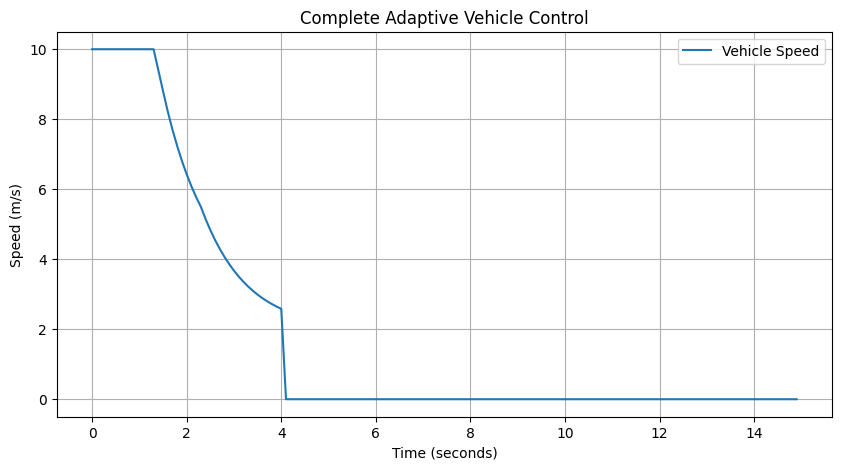

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    speed_history,
    label="Vehicle Speed"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Complete Adaptive Vehicle Control")

plt.grid()
plt.legend()
plt.show()

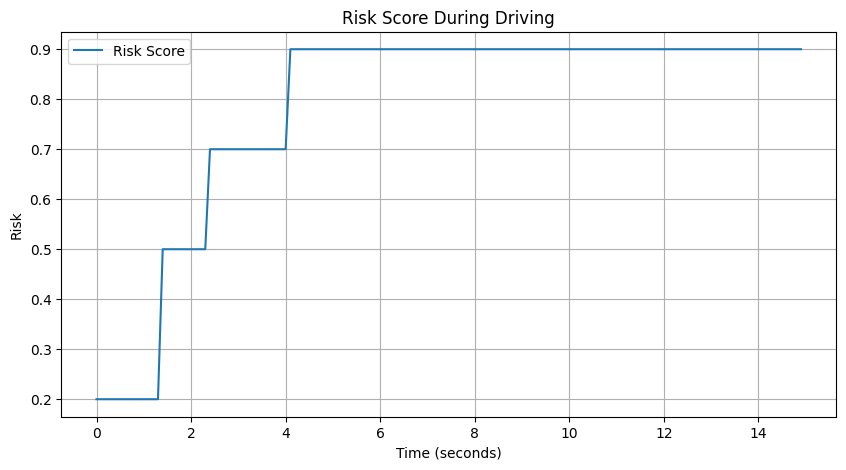

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    risk_history,
    label="Risk Score"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Risk")
plt.title("Risk Score During Driving")

plt.grid()
plt.legend()
plt.show()

In [ ]:
print("====================================")
print("VEHICLE CONTROL SYSTEM")
print("====================================")

print("Speed Controller       : READY")
print("Steering Controller    : READY")
print("Acceleration Control   : READY")
print("Braking Controller     : READY")
print("Emergency Braking      : READY")
print("Trajectory Following   : READY")
print("Safety Limits          : READY")
print("Risk Planner Interface : READY")

print("====================================")
print("STATUS: ALL MODULES READY")
print("====================================")

VEHICLE CONTROL SYSTEM
Speed Controller       : READY
Steering Controller    : READY
Acceleration Control   : READY
Braking Controller     : READY
Emergency Braking      : READY
Trajectory Following   : READY
Safety Limits          : READY
Risk Planner Interface : READY
STATUS: ALL MODULES READY


In [ ]:
# Performance Metrics

initial_speed = 10.0
final_speed = speed_history[-1]

max_speed_recorded = max(speed_history)

initial_distance = distance_history[0]
final_distance = distance_history[-1]

stopping_index = None

for i, speed in enumerate(speed_history):
    if speed <= 0.1:
        stopping_index = i
        break

if stopping_index is not None:
    stopping_time = time_history[stopping_index]
    stopping_distance = (
        initial_distance -
        distance_history[stopping_index]
    )
else:
    stopping_time = None
    stopping_distance = None

print("====================================")
print("VEHICLE CONTROL PERFORMANCE")
print("====================================")

print("Initial Speed      :", initial_speed, "m/s")
print("Final Speed        :", final_speed, "m/s")
print("Maximum Speed      :", max_speed_recorded, "m/s")
print("Initial Distance   :", initial_distance, "m")
print("Final Distance     :", final_distance, "m")

if stopping_time is not None:
    print("Stopping Time      :", stopping_time, "seconds")
    print("Stopping Distance  :", stopping_distance, "m")
else:
    print("Stopping Time      : Vehicle did not stop")

print("====================================")

VEHICLE CONTROL PERFORMANCE
Initial Speed      : 10.0 m/s
Final Speed        : 0.0 m/s
Maximum Speed      : 10.0 m/s
Initial Distance   : 29.0 m
Final Distance     : 1.784837384872146 m
Stopping Time      : 4.1000000000000005 seconds
Stopping Distance  : 27.215162615127856 m


In [ ]:
from collections import Counter

behavior_counts = Counter(behavior_history)

total_steps = len(behavior_history)

print("====================================")
print("BEHAVIOR PERFORMANCE")
print("====================================")

for behavior in [
    "CRUISE",
    "CAUTIOUS_APPROACH",
    "CREEP_NEGOTIATE",
    "SAFE_STOP"
]:
    count = behavior_counts.get(behavior, 0)
    percentage = (count / total_steps) * 100

    print(
        f"{behavior:20s}: "
        f"{count:4d} steps "
        f"({percentage:.2f}%)"
    )

print("====================================")

BEHAVIOR PERFORMANCE
CRUISE              :   14 steps (9.33%)
CAUTIOUS_APPROACH   :   10 steps (6.67%)
CREEP_NEGOTIATE     :   17 steps (11.33%)
SAFE_STOP           :  109 steps (72.67%)


In [ ]:
print("====================================")
print("RISK PERFORMANCE")
print("====================================")

print("Minimum Risk :", min(risk_history))
print("Maximum Risk :", max(risk_history))
print("Average Risk :", sum(risk_history) / len(risk_history))

print("====================================")

RISK PERFORMANCE
Minimum Risk : 0.2
Maximum Risk : 0.9
Average Risk : 0.7853333333333333


Final Results Visualization

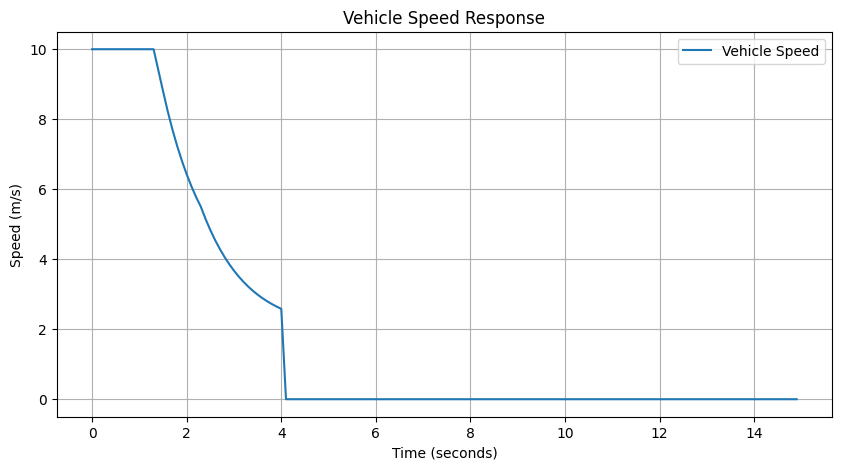

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    speed_history,
    label="Vehicle Speed"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed Response")

plt.grid()
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    distance_history,
    label="Obstacle Distance"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Distance (m)")
plt.title("Obstacle Distance During Driving")

plt.grid()
plt.legend()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    time_history,
    risk_history,
    label="Risk Score"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Risk Score")
plt.title("Risk Score Response")

plt.grid()
plt.legend()
plt.show()

In [ ]:
print("========================================")
print(" VEHICLE CONTROL SYSTEM - FINAL STATUS")
print("========================================")

print("✓ Speed Controller")
print("✓ Steering Controller")
print("✓ Acceleration / Deceleration")
print("✓ Normal Braking")
print("✓ Emergency Braking")
print("✓ Trajectory Following")
print("✓ Safety Limits")
print("✓ Risk Planner Integration")
print("✓ Adaptive Behavior")
print("✓ Performance Metrics")
print("✓ Final Visualization")

print("----------------------------------------")
print("GOOGLE COLAB PROTOTYPE: COMPLETE")
print("NEXT PHASE: MATLAB / SIMULINK")
print("========================================")